In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
data=yf.download("HDFCBANK.NS", start="2023-01-01", end="2026-01-01")
print(data)
prices=data["Close"]
print("===\n Closed Prices===")
print(prices.head(3))
print(prices.shape)

returns=prices.pct_change(fill_method=None)
returns=returns.dropna()
returns=returns.squeeze()
print(returns)
print("===\n RETURNS===")
print(returns.head(5))
print(returns.shape)

C:\Users\Admin\AppData\Local\Temp\ipykernel_21612\3656924952.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data=yf.download("HDFCBANK.NS", start="2023-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open      Volume
Ticker     HDFCBANK.NS HDFCBANK.NS HDFCBANK.NS HDFCBANK.NS HDFCBANK.NS
Date                                                                  
2023-01-02  783.677917  788.994845  778.794112  782.859956     4381378
2023-01-03  788.802307  790.558581  780.550269  780.550269     8378030
2023-01-04  774.704163  791.881828  773.236577  786.709275    10351600
2023-01-05  769.724060  778.553536  764.768067  777.085950    10941436
2023-01-06  767.173828  774.246970  759.378876  770.830691     9092462
...                ...         ...         ...         ...         ...
2025-12-24  997.200012  999.400024  993.000000  993.000000    13699996
2025-12-26  992.099976  997.200012  987.700012  996.000000     9360853
2025-12-29  991.700012  997.400024  987.200012  993.099976    13545749
2025-12-30  990.900024  995.000000  982.200012  990.200012    33155849
2025-12-31  991.200012  997.599976  987.599976  991.000000    10963454

[740 

In [3]:
mean=returns.mean()
std=returns.std()
x=returns
z_scores=(x-mean)/std

outliers=z_scores[np.abs(z_scores)>2]

print(f"Mean Return: {mean:.6f}")
print(f"Std Dev: {std:.6f}")
print(f"Total Outliers: {len(outliers)}")
print(outliers)
print(outliers.shape)

Mean Return: 0.000386
Std Dev: 0.011636
Total Outliers: 36
Date
2023-01-25   -2.407824
2023-02-03    2.938921
2023-03-10   -2.249235
2023-04-05    2.271971
2023-05-05   -5.114000
2023-07-05   -2.763196
2023-09-20   -3.480647
2023-12-04    2.950423
2024-01-17   -7.282809
2024-01-18   -2.903388
2024-01-23   -2.563453
2024-02-20    2.222782
2024-04-04    2.593161
2024-04-19    2.071172
2024-05-09   -2.070568
2024-06-03    2.247792
2024-06-04   -4.900777
2024-06-05    3.944643
2024-06-19    2.642052
2024-07-04   -2.049658
2024-07-05   -3.966511
2024-08-05   -2.281154
2024-08-13   -2.978731
2024-10-03   -2.233664
2024-10-07   -2.099148
2024-10-21    2.360751
2024-11-05    2.160291
2024-11-12   -2.373461
2025-01-03   -2.167571
2025-01-28    2.107652
2025-02-04    2.163957
2025-02-20   -2.028391
2025-04-01   -2.870064
2025-04-07   -2.851619
2025-04-15    2.732748
2025-05-12    3.036552
Name: HDFCBANK.NS, dtype: float64
(36,)


In [4]:
a=0.03
mean_abs=returns.abs().mean()
markov_bound=mean_abs/a

print(f"Markov Bound:{markov_bound:.4f}")
print(f"Markov says: probability of a 3% move is at most {markov_bound*100:.2f}%")

Markov Bound:0.2752
Markov says: probability of a 3% move is at most 27.52%


In [5]:
actual=returns[np.abs(returns)>=0.03]
print(f"Actual days with 3% move: {len(actual)}")
print(f"Actual probability: {len(actual)/len(returns)*100:.2f}%")

Actual days with 3% move: 17
Actual probability: 2.30%


In [6]:
k=0.03
variance=returns.var()
chebyshev_bound=(variance/k**2)

print(f"Chebyshev Bound: {chebyshev_bound:.4f}")
print(f"Chebyshev says: probability of a 3% move is at most {chebyshev_bound*100:.2f}%")

Chebyshev Bound: 0.1504
Chebyshev says: probability of a 3% move is at most 15.04%


In [7]:
print(f"Actual Probability:   {len(actual)/len(returns)*100:.2f}%")
print(f"Markov Bound:         {markov_bound*100:.2f}%")
print(f"Chebyshev Bound:      {chebyshev_bound*100:.2f}%")

Actual Probability:   2.30%
Markov Bound:         27.52%
Chebyshev Bound:      15.04%


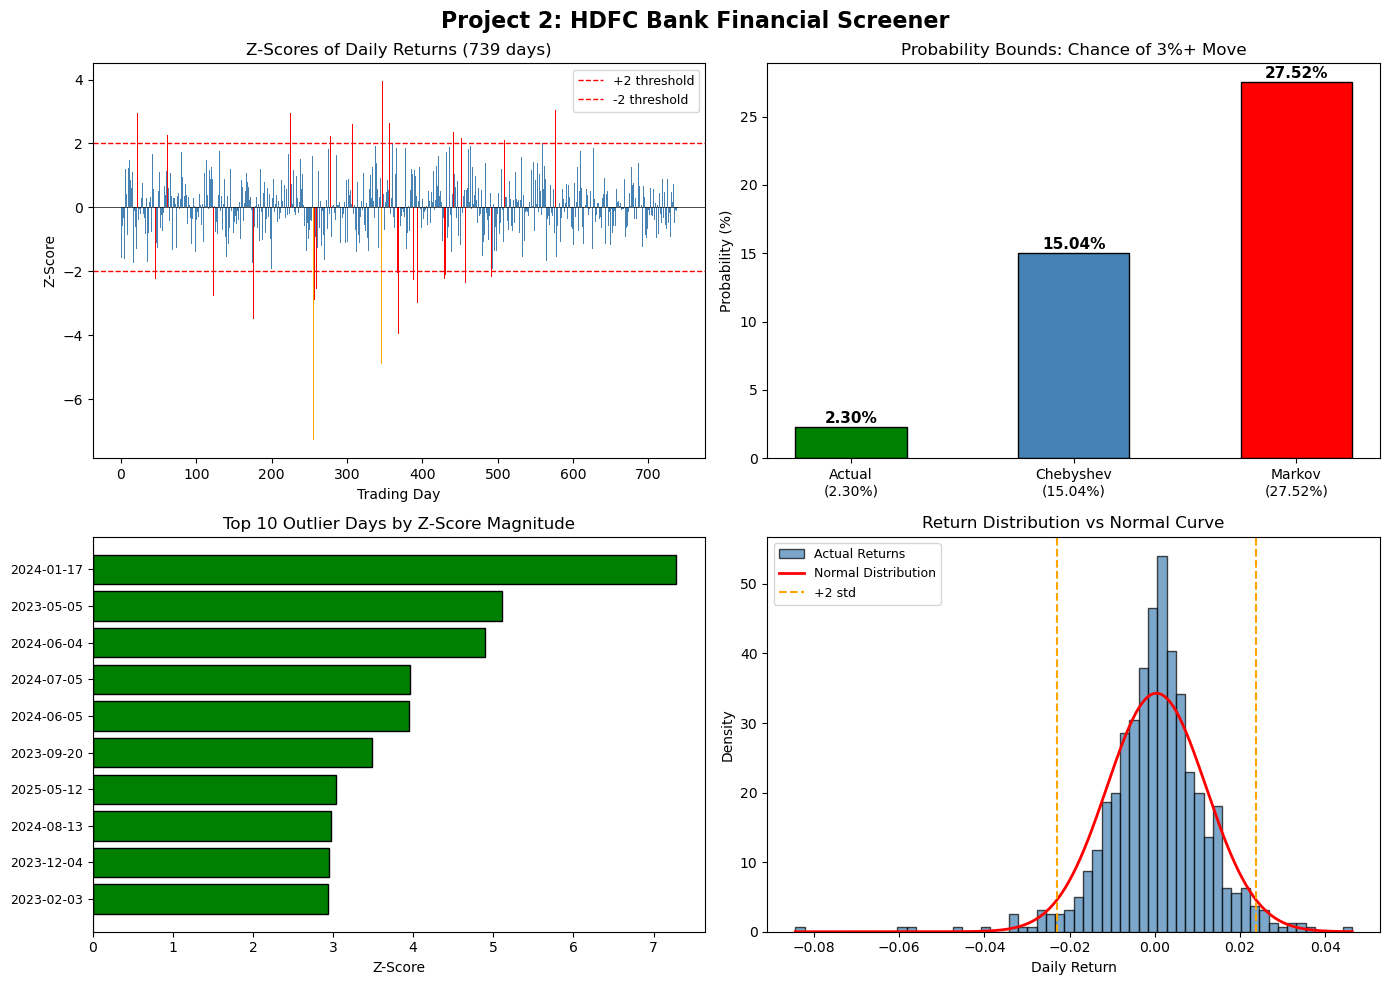


Mean Return:        0.000386
Std Deviation:      0.011636
Total Outliers:     36 out of 739 days
Actual Probability: 2.30%
Markov Bound:       27.52%
Chebyshev Bound:    15.04%


In [8]:
# ── PLOT ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Project 2: HDFC Bank Financial Screener", fontsize=16, fontweight='bold')

# Plot 1 - Z-scores over time
colors = ['orange' if abs(z) > 4 else 'red' if abs(z) > 2 else 'steelblue'
          for z in z_scores]
axes[0, 0].bar(range(len(z_scores)), z_scores, color=colors, width=1.0)
axes[0, 0].axhline(y=2,  color='red',    linestyle='--', linewidth=1, label='+2 threshold')
axes[0, 0].axhline(y=-2, color='red',    linestyle='--', linewidth=1, label='-2 threshold')
axes[0, 0].axhline(y=0,  color='black',  linestyle='-',  linewidth=0.5)
axes[0, 0].set_title("Z-Scores of Daily Returns (739 days)")
axes[0, 0].set_xlabel("Trading Day")
axes[0, 0].set_ylabel("Z-Score")
axes[0, 0].legend(fontsize=9)

# Plot 2 - Bounds comparison
methods = ['Actual\n(2.30%)', 'Chebyshev\n(15.04%)', 'Markov\n(27.52%)']
values  = [len(actual)/len(returns)*100, chebyshev_bound*100, markov_bound*100]
bar_colors = ['green', 'steelblue', 'red']
bars = axes[0, 1].bar(methods, values, color=bar_colors, edgecolor='black', width=0.5)
axes[0, 1].set_title("Probability Bounds: Chance of 3%+ Move")
axes[0, 1].set_ylabel("Probability (%)")
for bar, val in zip(bars, values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    f"{val:.2f}%", ha='center', fontsize=11, fontweight='bold')

# Plot 3 - Top outlier days
top_outliers = z_scores.abs().nlargest(10).sort_values()
bar_colors_out = ['red' if v < 0 else 'green' for v in top_outliers]
axes[1, 0].barh(range(len(top_outliers)), top_outliers.values,
                color=bar_colors_out, edgecolor='black')
axes[1, 0].set_yticks(range(len(top_outliers)))
axes[1, 0].set_yticklabels([str(d.date()) for d in top_outliers.index], fontsize=9)
axes[1, 0].axvline(x=0, color='black', linewidth=0.8)
axes[1, 0].set_title("Top 10 Outlier Days by Z-Score Magnitude")
axes[1, 0].set_xlabel("Z-Score")

# Plot 4 - Return distribution with normal overlay
axes[1, 1].hist(returns, bins=60, edgecolor='black', color='steelblue',
                density=True, alpha=0.7, label='Actual Returns')
x = np.linspace(returns.min(), returns.max(), 300)
axes[1, 1].plot(x, stats.norm.pdf(x, mean, std),
                color='red', linewidth=2, label='Normal Distribution')
axes[1, 1].axvline(x=mean + 2*std, color='orange', linestyle='--',
                   linewidth=1.5, label='+2 std')
axes[1, 1].axvline(x=mean - 2*std, color='orange', linestyle='--', linewidth=1.5)
axes[1, 1].set_title("Return Distribution vs Normal Curve")
axes[1, 1].set_xlabel("Daily Return")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── PRINT SUMMARY ─────────────────────────────────────────────
print(f"\nMean Return:        {mean:.6f}")
print(f"Std Deviation:      {std:.6f}")
print(f"Total Outliers:     {len(outliers)} out of {len(returns)} days")
print(f"Actual Probability: {len(actual)/len(returns)*100:.2f}%")
print(f"Markov Bound:       {markov_bound*100:.2f}%")
print(f"Chebyshev Bound:    {chebyshev_bound*100:.2f}%")